# ENGE707 — Image classification experiments

**Single pipeline:** inspect data → compare three staged CNNs → inspect errors and heatmaps. Minimal code, no report text.

Use in `C:\AI Workspace\Kaggle`, beside `train_labels.csv`, `train/train/` and the existing `staged_checkpoints/` folder. **Existing checkpoints load automatically**; missing checkpoints trigger training. Set `RETRAIN = True` to rerun everything.

Models: **Scratch V1 (94K parameters)**, **Scratch V2 (1.56M)**, **pretrained ResNet-18 (11.18M)**. Same stratified validation split and padded RGB input. V2 is compared at **Stage 2**, because its joint stage has not yet been run.

### 1. Setup

In [1]:
from pathlib import Path
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms.functional import resized_crop, InterpolationMode
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

ROOT = Path.cwd()
TRAIN_DIR = ROOT / 'train' / 'train'
CHECKPOINTS = ROOT / 'staged_checkpoints'
CHECKPOINTS.mkdir(exist_ok=True)
assert TRAIN_DIR.is_dir(), f'Expected training images in {TRAIN_DIR}'

df = pd.read_csv(ROOT / 'train_labels.csv', dtype={'image_id': str})
class_names = sorted(df['class'].unique())
species_names, feature_names = ['Cat', 'Dog'], ['Eye', 'Face', 'Mouth', 'Nose']
assert class_names == [s+f for s in species_names for f in feature_names]
assert not df[['image_id', 'class']].isna().any().any() and df['image_id'].is_unique
train_data, val_data = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])
train_data, val_data = train_data.reset_index(drop=True), val_data.reset_index(drop=True)

SEED, BATCH, WORKERS = 42, 64, 2
RETRAIN = False  # True = retrain all stages even if checkpoints exist
RUN_V2_JOINT = False  # V2 Stage 3 was not part of our measured comparison
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Train {len(train_data):,} | Validation {len(val_data):,} | Device {device}')
print(df['class'].value_counts().sort_index().to_string())

Train 50,928 | Validation 12,732 | Device cuda
class
CatEye      13884
CatFace      6942
CatMouth     6942
CatNose      6942
DogEye      11580
DogFace      5790
DogMouth     5790
DogNose      5790


### 2. Image dataset (Windows/Jupyter multiprocessing helper)

In [2]:
%%writefile staged_dataset.py
from pathlib import Path
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor

FEATURES = {'Eye': 0, 'Face': 1, 'Mouth': 2, 'Nose': 3}

class StagedImages(Dataset):
    def __init__(self, data, directory, mode='pad'):
        self.samples = [
            (Path(directory) / f'{image_id}.jpg', int(label.startswith('Dog')), FEATURES[label[3:]])
            for image_id, label in data[['image_id','class']].itertuples(index=False, name=None)
        ]
        self.mode = mode

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, species, feature = self.samples[i]
        with Image.open(path) as img:
            img = img.convert('RGB')
            if self.mode == 'pad':
                img = ImageOps.pad(img, (128,128), method=Image.Resampling.BILINEAR,
                                   color=(114,114,114))
            else:
                img = img.resize((128,128), Image.Resampling.BILINEAR)
            x = to_tensor(img)
        return x, species, feature, species * 4 + feature

Overwriting staged_dataset.py


In [3]:
import importlib, staged_dataset
importlib.reload(staged_dataset)
StagedImages = staged_dataset.StagedImages

def make_loader(data, shuffle=False, mode='pad', workers=WORKERS):
    options = dict(num_workers=workers, pin_memory=(device.type == 'cuda'))
    if workers: options.update(persistent_workers=False, prefetch_factor=1)
    return DataLoader(StagedImages(data, TRAIN_DIR, mode), batch_size=BATCH,
                      shuffle=shuffle, **options)

train_loader, val_loader = make_loader(train_data, True), make_loader(val_data)
print('Input shape:', tuple(next(iter(train_loader))[0].shape))

Input shape: (64, 3, 128, 128)


### 3. Data investigations — size, colour and geometry

In [4]:
# Inspect original JPEG dimensions; never modify image files
records = []
for image_id, label in df[['image_id','class']].itertuples(index=False, name=None):
    with Image.open(TRAIN_DIR / f'{image_id}.jpg') as img:
        w, h, mode = *img.size, img.mode
    records.append((image_id, label, w, h, mode))
meta = pd.DataFrame(records, columns=['image_id','class','width','height','mode'])
meta['short_side'] = meta[['width','height']].min(axis=1)
meta['ratio'] = meta['width'] / meta['height']
meta['square'] = meta['width'] == meta['height']
print('Image modes:', meta['mode'].value_counts().to_dict())
print('Shortest-side percentiles:', np.percentile(meta['short_side'], [0,25,50,75,95,100]))
summary = meta.groupby('class').agg(
    count=('class','size'), median_px=('short_side','median'),
    median_ratio=('ratio','median'), square_pct=('square',lambda x:100*x.mean()),
    wide_pct=('ratio',lambda x:100*(x>1.25).mean())
)
display(summary.round(2))

Image modes: {'RGB': 63660}
Shortest-side percentiles: [   4.     50.     78.    126.    268.05 2219.  ]


,count,median_px,median_ratio,square_pct,wide_pct
class,,,,,
CatEye,13884,68.0,1.00,99.91,0.02
CatFace,6942,178.0,0.83,0.58,3.08
CatMouth,6942,80.0,1.42,0.00,99.94
CatNose,6942,68.0,1.00,98.92,0.23
DogEye,11580,62.0,1.00,99.94,0.00
DogFace,5790,155.0,1.00,61.71,0.00
DogMouth,5790,77.0,1.35,0.02,99.83
DogNose,5790,62.0,1.00,99.90,0.00


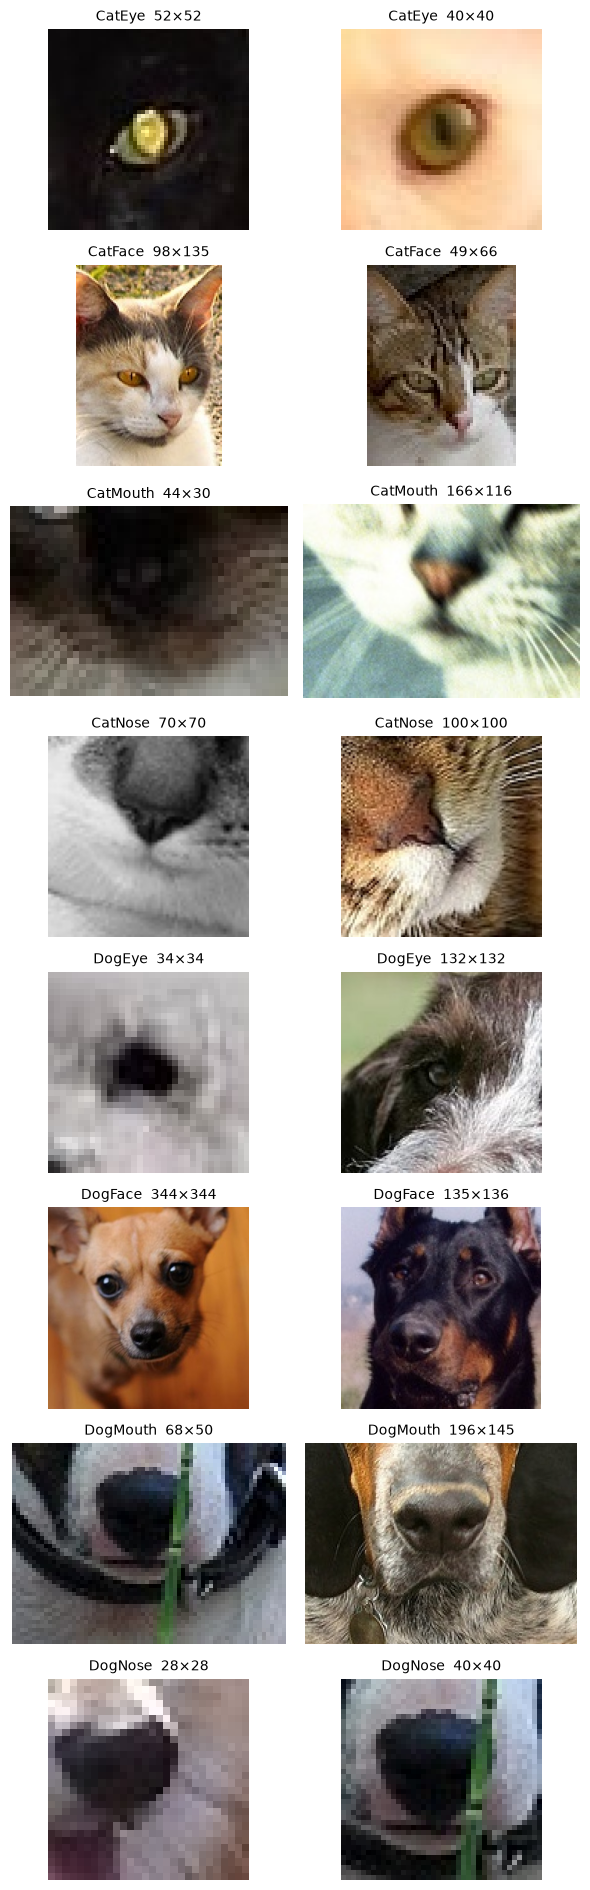

In [5]:
# Example original images: two per class
sample = df.groupby('class',sort=True).sample(n=2,random_state=42)
fig, axes = plt.subplots(8,2,figsize=(6,19))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    with Image.open(TRAIN_DIR / f"{r['image_id']}.jpg") as img:
        ax.imshow(img); w,h=img.size
    ax.set_title(f"{r['class']}  {w}×{h}", fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

**Preprocessing experiments already completed** (historical results; separate earlier training runs):

| Input processing | Best validation accuracy | Training time |
|---|---:|---:|
| Stretch every image to 128×128 | 72.54% | 232.43 s |
| Variable size, padded per batch (maximum 256px) | 53.85% | 462.80 s |
| **Resize proportionally + pad to 128×128** | **76.78%** | 243.21 s |

The remaining experiments use proportional padding. The variable-resolution attempt was inefficient because small images occupied little of the dynamically padded batch.

In [6]:
# Geometry-only diagnostic: does width/height identify the Mouth label?
vgeom = val_data[['image_id','class']].merge(meta[['image_id','ratio','short_side']], on='image_id', validate='one_to_one')
is_mouth = vgeom['class'].str.endswith('Mouth')
wide = vgeom['ratio'] > 1.25
print('Mouth from aspect ratio alone:', f'{accuracy_score(is_mouth,wide):.2%}')
print(classification_report(is_mouth, wide, target_names=['Not Mouth','Mouth'], digits=3))
print('Exceptions by class:\n',vgeom.loc[wide!=is_mouth,'class'].value_counts().to_string())

Mouth from aspect ratio alone: 99.65%
              precision    recall  f1-score   support

   Not Mouth      1.000     0.996     0.998     10186
       Mouth      0.984     0.999     0.991      2546

    accuracy                          0.997     12732
   macro avg      0.992     0.997     0.995     12732
weighted avg      0.997     0.997     0.997     12732

Exceptions by class:
 class
CatFace     38
CatNose      2
DogMouth     2
CatEye       1
CatMouth     1


### 4. Three models — same two classification heads

In [7]:
class StagedCNN(nn.Module):  # Scratch V1: 94K parameters
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1)))
        self.species_head, self.feature_head = nn.Linear(128,2), nn.Linear(128,4)
    def forward(self,x):
        z = self.encoder(x).flatten(1)
        return self.species_head(z),self.feature_head(z)

class ResidualBlock(nn.Module):
    def __init__(self,cin,cout,stride=1):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(cin,cout,3,stride,padding=1,bias=False),nn.BatchNorm2d(cout),nn.ReLU(),
            nn.Conv2d(cout,cout,3,padding=1,bias=False),nn.BatchNorm2d(cout))
        self.skip = (nn.Identity() if cin==cout and stride==1 else
                     nn.Sequential(nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout)))
        self.relu = nn.ReLU()
    def forward(self,x):
        return self.relu(self.layers(x)+self.skip(x))

class ScratchCNNV2(nn.Module):  # Residual blocks, BatchNorm, spatial average + max pooling
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(),
            ResidualBlock(32,32),ResidualBlock(32,64,2),
            ResidualBlock(64,128,2),ResidualBlock(128,256,2))
        self.avg_pool,self.max_pool = nn.AdaptiveAvgPool2d((2,2)),nn.AdaptiveMaxPool2d((1,1))
        def head(n): return nn.Sequential(nn.Linear(256*5,128),nn.ReLU(),nn.Dropout(0.2),nn.Linear(128,n))
        self.species_head,self.feature_head = head(2),head(4)
    def forward(self,x):
        z = self.encoder(x)
        z = torch.cat((self.avg_pool(z).flatten(1),self.max_pool(z).flatten(1)),dim=1)
        return self.species_head(z),self.feature_head(z)

class StagedResNet(nn.Module):
    def __init__(self,pretrained=False):
        super().__init__()
        self.encoder = resnet18(weights=ResNet18_Weights.DEFAULT if pretrained else None)
        features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.species_head,self.feature_head = nn.Linear(features,2),nn.Linear(features,4)
        self.register_buffer('mean',torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('std',torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self,x):
        z = self.encoder((x-self.mean)/self.std)
        return self.species_head(z),self.feature_head(z)

### 5. Train or restore checkpoints

In [8]:
criterion = nn.CrossEntropyLoss()

def evaluate(net, loader=val_loader):
    net.eval()
    true, pred, sp_true, sp_pred, ft_true, ft_pred = [],[],[],[],[],[]
    with torch.inference_mode():
        for images,s,f,y in loader:
            with autocast('cuda',dtype=torch.float16,enabled=device.type=='cuda'):
                a,b = net(images.to(device,non_blocking=True))
            ap,bp = a.argmax(1).cpu(),b.argmax(1).cpu()
            true.extend(y.tolist()); pred.extend((ap*4+bp).tolist())
            sp_true.extend(s.tolist()); sp_pred.extend(ap.tolist())
            ft_true.extend(f.tolist()); ft_pred.extend(bp.tolist())
    return dict(true=np.array(true),pred=np.array(pred),
                species=accuracy_score(sp_true,sp_pred),feature=accuracy_score(ft_true,ft_pred),
                accuracy=accuracy_score(true,pred),macro_f1=f1_score(true,pred,average='macro'))

def train_stage(net, kind, stage, epochs, filename):
    # Freeze/unfreeze according to training stage
    net.encoder.requires_grad_(stage!='feature')
    net.species_head.requires_grad_(stage!='feature')
    net.feature_head.requires_grad_(stage!='species')
    if kind=='resnet':
        net.encoder.requires_grad_(False)
        if stage=='joint': net.encoder.layer4.requires_grad_(True)

    if kind=='resnet' and stage=='joint':
        opt = torch.optim.AdamW([
            {'params':net.encoder.layer4.parameters(),'lr':1e-5},
            {'params':net.species_head.parameters(),'lr':1e-4},
            {'params':net.feature_head.parameters(),'lr':1e-4}],weight_decay=1e-4)
    else:
        pars = (p for p in net.parameters() if p.requires_grad)
        lr = 3e-4 if kind=='v1' and stage=='joint' else (1e-4 if stage=='joint' else 1e-3)
        opt = (torch.optim.AdamW(pars,lr=lr,weight_decay=1e-4) if kind=='v2'
               else torch.optim.Adam(pars,lr=lr))
    scaler = GradScaler('cuda',enabled=device.type=='cuda')
    key = ('species' if stage=='species' else 'accuracy' if stage=='joint' or kind=='v2' else 'feature')
    best = -1
    for epoch in range(1,epochs+1):
        t0=time.perf_counter(); net.train()
        if stage=='feature' or kind=='resnet': net.encoder.eval()  # Freeze BatchNorm statistics
        for images,s,f,_ in train_loader:
            images=images.to(device,non_blocking=True)
            s,f=s.to(device,non_blocking=True),f.to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda',dtype=torch.float16,enabled=device.type=='cuda'):
                a,b=net(images)
                loss=(criterion(a,s) if stage=='species' else criterion(b,f) if stage=='feature'
                      else criterion(a,s)+criterion(b,f))
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        r=evaluate(net)
        if r[key]>best:
            best=r[key]; torch.save(net.state_dict(),filename)
        print(f'{kind} {stage:7} {epoch}/{epochs} | Species {r["species"]:.2%} | '
              f'Feature {r["feature"]:.2%} | 8-class {r["accuracy"]:.2%} | '
              f'{time.perf_counter()-t0:.1f}s')
    net.load_state_dict(torch.load(filename,map_location=device,weights_only=True))

def fit_or_load(kind, model_class, stages, final_path, pretrained=False):
    torch.manual_seed(SEED)
    net = (model_class(pretrained=pretrained and (RETRAIN or not final_path.exists()))
           if kind=='resnet' else model_class()).to(device)
    if final_path.exists() and not RETRAIN:
        net.load_state_dict(torch.load(final_path,map_location=device,weights_only=True))
        print(f'{kind}: loaded {final_path.name}')
    else:
        for stage,epochs,path in stages:
            if path.exists() and not RETRAIN:
                net.load_state_dict(torch.load(path,map_location=device,weights_only=True))
                print(f'{kind}: loaded {path.name}')
            else:
                train_stage(net,kind,stage,epochs,path)
    return net

In [9]:
# V1: existing 3-stage scratch model
v1_stages = [('species',8,CHECKPOINTS/'best_species.pt'),
             ('feature',5,CHECKPOINTS/'best_feature.pt'),
             ('joint',8,CHECKPOINTS/'best_joint.pt')]
model = fit_or_load('v1',StagedCNN,v1_stages,v1_stages[-1][2])

v1: loaded best_joint.pt


In [10]:
# V2: Stage 2 is the comparison checkpoint (Stage 3 has not yet been measured)
v2_stages = [('species',8,CHECKPOINTS/'scratch_v2_stage1.pt'),
             ('feature',6,CHECKPOINTS/'scratch_v2_stage2.pt')]
if RUN_V2_JOINT:
    v2_stages.append(('joint',3,CHECKPOINTS/'scratch_v2_stage3.pt'))
scratch_v2 = fit_or_load('v2',ScratchCNNV2,v2_stages,v2_stages[-1][2])

v2: loaded scratch_v2_stage2.pt


In [11]:
# Pretrained ResNet-18: train the heads first, then fine-tune layer4
resnet_stages = [('species',5,CHECKPOINTS/'resnet_stage1_species.pt'),
                 ('feature',5,CHECKPOINTS/'resnet_stage2_feature.pt'),
                 ('joint',3,CHECKPOINTS/'resnet_stage3_joint.pt')]
resnet_model = fit_or_load('resnet',StagedResNet,resnet_stages,resnet_stages[-1][2],pretrained=True)

resnet: loaded resnet_stage3_joint.pt


### 6. Compare models and errors

,Model,Parameters,Cat/Dog %,Feature %,8-class %,Macro F1
0,Scratch V1,94022,92.067,87.614,81.503,0.819
1,Scratch V2,1555110,98.657,96.772,95.712,0.957
2,ResNet-18,11179590,99.434,99.537,98.995,0.990


Training budgets differ: V1 (8/5/8), V2 (8/6), ResNet (5/5/3) epochs.


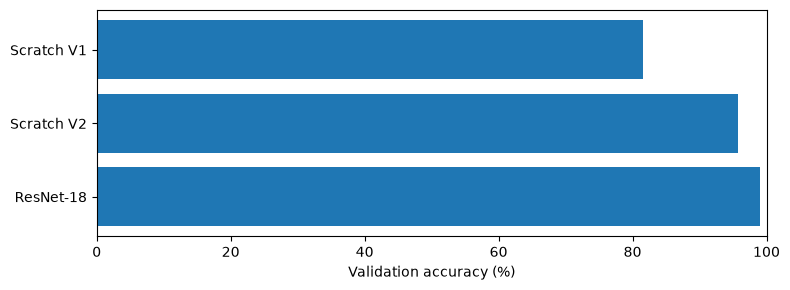

In [12]:
models = {'Scratch V1':model, 'Scratch V2':scratch_v2, 'ResNet-18':resnet_model}
results = {name:evaluate(net) for name,net in models.items()}
rows=[]
for name,net in models.items():
    r=results[name]
    rows.append([name,sum(p.numel() for p in net.parameters()),
                 100*r['species'],100*r['feature'],100*r['accuracy'],r['macro_f1']])
comparison=pd.DataFrame(rows,columns=['Model','Parameters','Cat/Dog %','Feature %','8-class %','Macro F1'])
display(comparison.round(3))
print('Training budgets differ: V1 (8/5/8), V2 (8/6), ResNet (5/5/3) epochs.')
fig,ax=plt.subplots(figsize=(8,3))
ax.barh(comparison['Model'],comparison['8-class %']); ax.set(xlim=(0,100),xlabel='Validation accuracy (%)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

In [22]:
# Classification reports and clearer confusion matrices

for ax, (name, r) in zip(axes, results.items()):
    print(f"\n{name}:")
    print(classification_report(
        r["true"], r["pred"], target_names=class_names, digits=3
    ))


Scratch V1:
              precision    recall  f1-score   support

      CatEye      0.811     0.860     0.835      2777
     CatFace      0.890     0.927     0.908      1388
    CatMouth      0.957     0.996     0.976      1388
     CatNose      0.732     0.731     0.732      1389
      DogEye      0.785     0.630     0.699      2316
     DogFace      0.749     0.821     0.784      1158
    DogMouth      0.989     0.974     0.981      1158
     DogNose      0.618     0.662     0.639      1158

    accuracy                          0.815     12732
   macro avg      0.816     0.825     0.819     12732
weighted avg      0.815     0.815     0.813     12732


Scratch V2:
              precision    recall  f1-score   support

      CatEye      0.963     0.971     0.967      2777
     CatFace      0.970     0.970     0.970      1388
    CatMouth      0.986     0.998     0.992      1388
     CatNose      0.945     0.948     0.946      1389
      DogEye      0.949     0.923     0.936      231

In [14]:
# Top mistakes, showing where V2 and ResNet correct V1's errors
truth=results['Scratch V1']['true']
assert all(np.array_equal(truth,r['true']) for r in results.values())
issues=val_data[['image_id','class']].copy()
for name,r in results.items(): issues[name]=[class_names[i] for i in r['pred']]
issues['V1 wrong'] = issues['Scratch V1'] != issues['class']
issues['V2 fixed'] = issues['V1 wrong'] & (issues['Scratch V2']==issues['class'])
issues['ResNet fixed'] = issues['V1 wrong'] & (issues['ResNet-18']==issues['class'])
print('V1 errors:', issues['V1 wrong'].sum(), '| Fixed by V2:', issues['V2 fixed'].sum(),
      '| Fixed by ResNet:', issues['ResNet fixed'].sum())
for name in models:
    mistakes=issues[issues[name]!=issues['class']]
    print(f'\n{name} top confusions:\n', mistakes.groupby(['class',name]).size().sort_values(ascending=False).head(8).to_string())

V1 errors: 2355 | Fixed by V2: 2018 | Fixed by ResNet: 2287

Scratch V1 top confusions:
 class    Scratch V1
DogEye   CatEye        309
         DogNose       283
CatNose  CatEye        216
DogNose  DogEye        171
CatEye   CatNose       168
         DogEye        161
DogEye   DogFace       154
DogNose  DogFace       113

Scratch V2 top confusions:
 class    Scratch V2
DogEye   DogNose       72
DogNose  DogEye        57
DogEye   CatEye        53
CatNose  CatEye        39
DogEye   DogFace       38
CatEye   CatNose       37
DogNose  DogFace       36
CatEye   DogEye        28

ResNet-18 top confusions:
 class     ResNet-18
CatEye    DogEye       30
CatNose   DogNose      17
CatEye    CatNose      12
CatNose   CatEye       11
CatMouth  DogMouth      7
DogEye    CatEye        7
DogNose   DogEye        7
DogEye    DogNose       7


In [15]:
# Validation accuracy by original resolution, same bins for each model
bins=[0,32,64,128,224,np.inf]
labels=['<32','32–63','64–127','128–223','224+']
resolution=val_data[['image_id','class']].merge(meta[['image_id','short_side']],on='image_id',validate='one_to_one')
resolution['bin']=pd.cut(resolution['short_side'],bins,labels=labels,right=False)
for name,r in results.items(): resolution[name]=(r['true']==r['pred'])
resolution_table=resolution.groupby('bin',observed=False)[list(models)].agg(['mean','size'])
print('Accuracy (%) by original shortest side:')
display((100*resolution.groupby('bin',observed=False)[list(models)].mean()).round(1))
print('Samples per bin:', resolution['bin'].value_counts().reindex(labels).to_dict())

Accuracy (%) by original shortest side:


,Scratch V1,Scratch V2,ResNet-18
bin,,,
<32,74.7,92.5,95.5
32–63,79.8,95.0,98.8
64–127,81.7,96.5,99.5
128–223,84.4,96.1,99.5
224+,86.7,96.4,99.3


Samples per bin: {'<32': 797, '32–63': 3913, '64–127': 4905, '128–223': 2055, '224+': 1062}


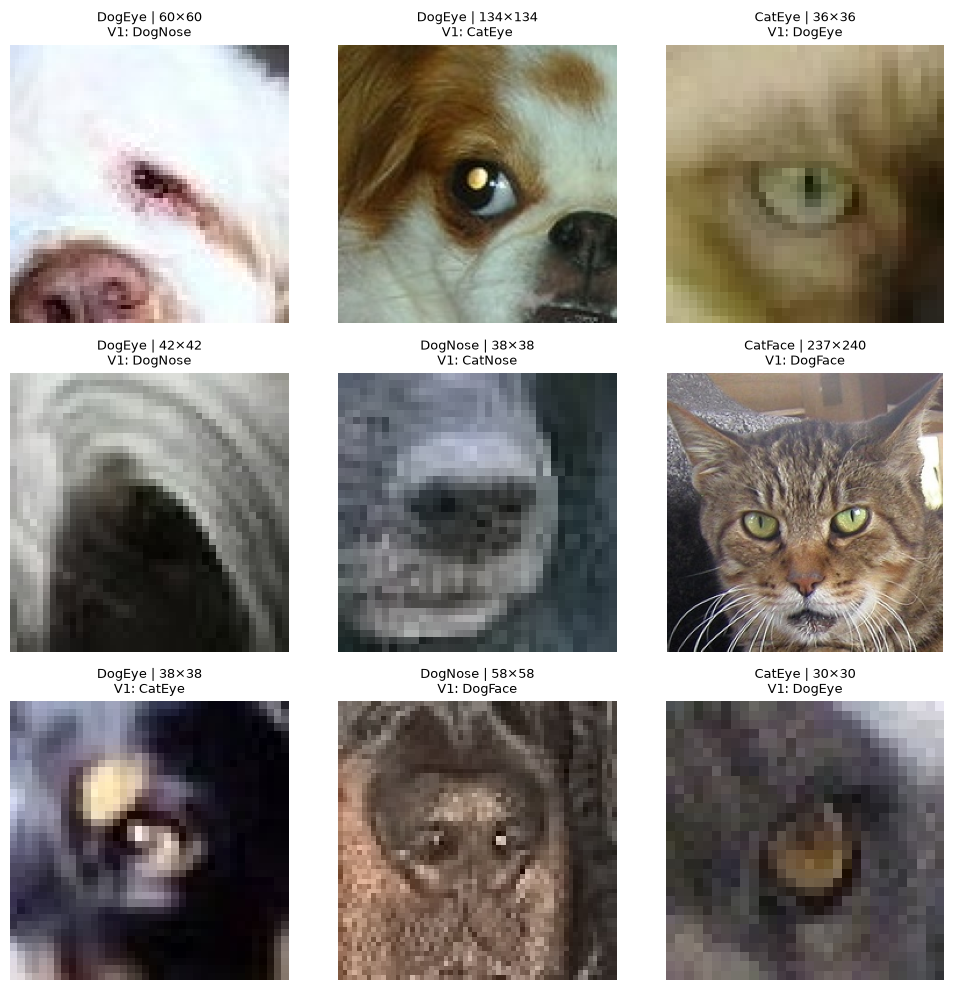

In [16]:
# Visualise errors that V1 missed but the improved models recognise
selected=issues[issues['V2 fixed'] & issues['ResNet fixed']].head(9)
fig,axes=plt.subplots(3,3,figsize=(10,10))
for ax,(_,row) in zip(axes.flat,selected.iterrows()):
    with Image.open(TRAIN_DIR/f"{row['image_id']}.jpg") as im:
        ax.imshow(im); w,h=im.size
    ax.set_title(f"{row['class']} | {w}×{h}\nV1: {row['Scratch V1']}",fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(selected):]: ax.axis('off')
plt.tight_layout();plt.show()

### 7. Centre-crop stress test (diagnostic, not new training)

In [17]:
class CenterView(Dataset):
    def __init__(self,base,keep): self.base,self.keep=base,keep
    def __len__(self): return len(self.base)
    def __getitem__(self,i):
        img,s,f,y=self.base[i]
        n=round(128*self.keep); offset=(128-n)//2
        return resized_crop(img,offset,offset,n,n,[128,128],InterpolationMode.BILINEAR),s,f,y

rows=[]
base=StagedImages(val_data,TRAIN_DIR)
for keep in [1.0,0.85,0.70]:
    loader=DataLoader(CenterView(base,keep),batch_size=BATCH,num_workers=0)
    for name,net in models.items():
        r=evaluate(net,loader)
        rows.append([name,f'{keep:.0%}',100*r['species'],100*r['feature'],100*r['accuracy']])
display(pd.DataFrame(rows,columns=['Model','Centre retained','Cat/Dog %','Feature %','8-class %']).round(2))
print('Cropping padded images changes context and apparent size; it does not prove a centre-label rule.')

,Model,Centre retained,Cat/Dog %,Feature %,8-class %
0,Scratch V1,100%,92.07,87.61,81.50
1,Scratch V2,100%,98.66,96.77,95.71
2,ResNet-18,100%,99.43,99.54,98.99
3,Scratch V1,85%,89.15,65.62,59.35
4,Scratch V2,85%,97.34,77.31,75.71
5,ResNet-18,85%,99.24,95.50,94.80
6,Scratch V1,70%,87.01,55.73,48.70
7,Scratch V2,70%,95.63,72.90,69.73
8,ResNet-18,70%,98.67,74.90,73.85


Cropping padded images changes context and apparent size; it does not prove a centre-label rule.


### 8. Grad-CAM — same Dog/Eye targets, same images

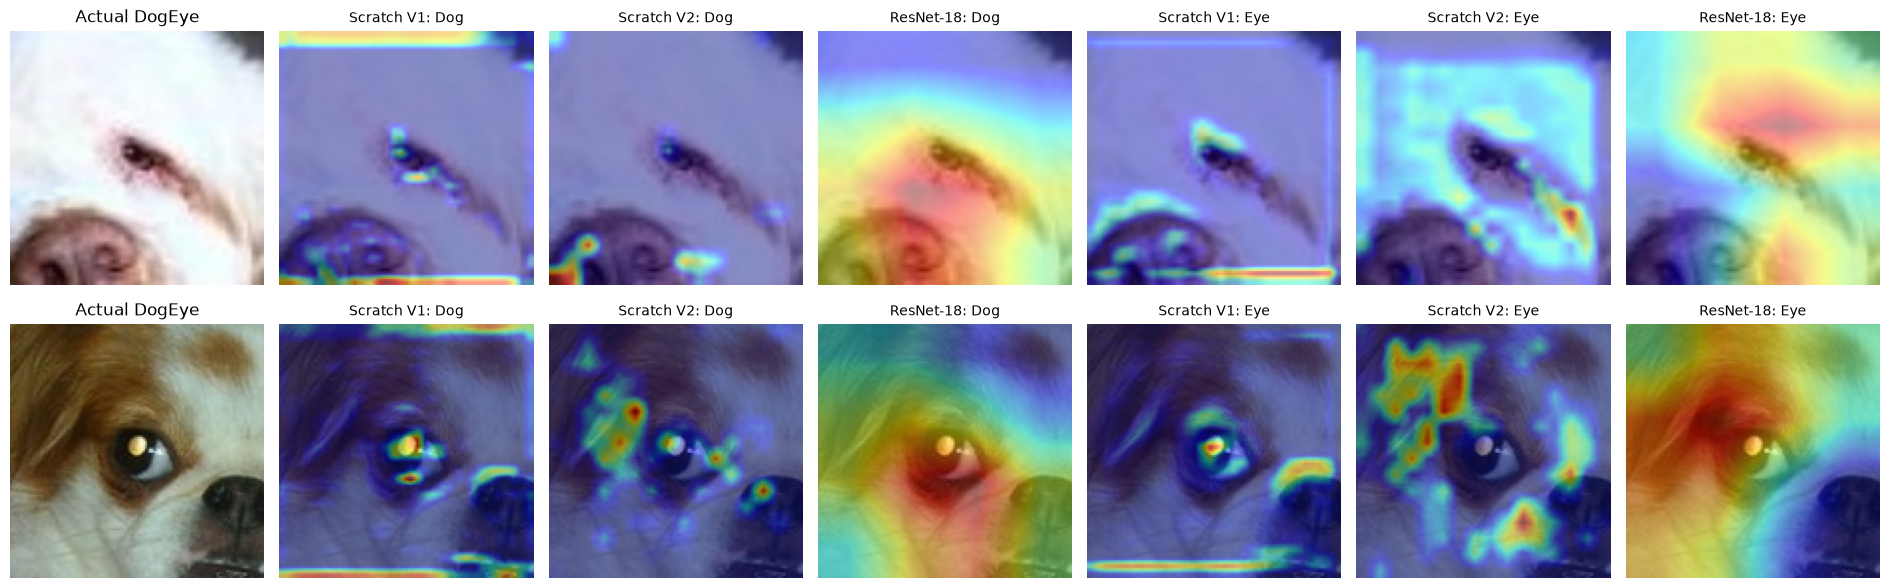

Heatmap resolution: V1 32×32, V2 16×16, ResNet 4×4. Brightness is not confidence.


In [18]:
import torch.nn.functional as F

def target_cam(net,layer,img,head,target):
    saved={}
    hook=layer.register_forward_hook(lambda m,inp,out: saved.update(features=out))
    try:
        net.eval()
        with torch.enable_grad():
            x=img.unsqueeze(0).to(device).detach().requires_grad_(True)
            s,f=net(x)
            feature_map=saved['features']
            grads=torch.autograd.grad((s if head=='species' else f)[0,target],feature_map)[0]
            cam=F.relu((grads.mean(dim=(2,3),keepdim=True)*feature_map).sum(dim=1,keepdim=True))
            cam=F.interpolate(cam.float(),size=img.shape[-2:],mode='bilinear',align_corners=False)[0,0]
            cam=cam.detach().cpu()
            return (cam-cam.min())/(cam.max()-cam.min()+1e-6)
    finally:
        hook.remove()

layers={'Scratch V1':model.encoder[6], 'Scratch V2':scratch_v2.encoder[-1],
        'ResNet-18':resnet_model.encoder.layer4}
# Choose DogEye images misclassified by V1 but correct in both other models
positions=np.flatnonzero((truth==class_names.index('DogEye')) &
    (results['Scratch V1']['pred']!=truth) &
    (results['Scratch V2']['pred']==truth) & (results['ResNet-18']['pred']==truth))[:2]
if len(positions)==0: positions=np.flatnonzero(truth==class_names.index('DogEye'))[:2]

fig,axes=plt.subplots(len(positions),7,figsize=(19,3.1*len(positions)),squeeze=False)
for row,i in enumerate(positions):
    image,_,_,_=base[int(i)]
    original=image.permute(1,2,0).cpu().numpy()
    axes[row,0].imshow(original);axes[row,0].set_title('Actual DogEye')
    for col,(head,target) in enumerate([('species',1),('feature',0)]):
        for j,(name,net) in enumerate(models.items()):
            ax=axes[row,1+3*col+j]
            ax.imshow(original)
            cam=target_cam(net,layers[name],image,head,target)
            ax.imshow(cam,cmap='jet',alpha=.45,vmin=0,vmax=1)
            ax.set_title(f'{name}: {"Dog" if col==0 else "Eye"}',fontsize=10)
    for ax in axes[row]: ax.axis('off')
plt.tight_layout();plt.show()
print('Heatmap resolution: V1 32×32, V2 16×16, ResNet 4×4. Brightness is not confidence.')

### 9. Conclusions / checks

- **Scratch V1:** simplest model; baseline for the staged approach.
- **Scratch V2:** residual blocks, BatchNorm and richer pooling greatly improve accuracy *without* pretrained weights.
- **ResNet-18:** most accurate in our validation experiments; strong ImageNet pretraining plus selective fine-tuning.
- **Geometry shortcut:** aspect ratio almost entirely determines whether a crop is labelled *Mouth*. Treat this as a dataset bias, not proof of anatomical recognition.
- **Grad-CAM:** shows approximate class-specific regions, **not** a causal explanation; coarse ResNet maps are naturally smoother.
- **Fairness:** epoch budgets differ, and repeated experimentation uses the same validation split. Audit duplicates and use genuinely unseen data before claiming external generalisation.

**No original images or labels are rewritten.** Save the best model checkpoints and use the same preprocessing for future inference.

### Optional — exact train/validation duplicate audit

In [19]:
# Optional diagnostic. Identical files across splits would inflate validation accuracy.
CHECK_EXACT_DUPLICATES = False
if CHECK_EXACT_DUPLICATES:
    import hashlib
    def digest(image_id):
        h=hashlib.sha256()
        with open(TRAIN_DIR/f'{image_id}.jpg','rb') as file:
            for chunk in iter(lambda:file.read(1<<20),b''): h.update(chunk)
        return h.digest()
    train_hashes={digest(i) for i in train_data['image_id']}
    overlap=[i for i in val_data['image_id'] if digest(i) in train_hashes]
    print('Exact duplicate validation files:',len(overlap))
    print('This does not detect resized or near-duplicate pictures.')